In [1]:
import argparse
import os
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torch.utils.data
from torch.autograd import Variable
import torch.nn.functional as F
import numpy as np
import time
import math
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
from models import *
from dataloader import KITTILoader as DA
from dataloader import preprocess

In [3]:
# GPU smoke test
import torch
from models.stackhourglass import PSMNet as StackPSM

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

model = StackPSM(192).to(device)
model.eval()

B, C, H, W = 1, 3, 256, 512  # reduce H,W if you have limited GPU memory
left = torch.randn(B, C, H, W, device=device)
right = torch.randn(B, C, H, W, device=device)

try:
    with torch.no_grad():
        out = model(left, right)
    print('Forward pass successful. Output type:', type(out))
    if isinstance(out, torch.Tensor):
        print('Output shape:', out.shape)
    elif isinstance(out, (list, tuple)):
        print('Tuple lengths/shapes:', [x.shape if isinstance(x, torch.Tensor) else str(type(x)) for x in out])
except Exception as e:
    print('Forward failed:', type(e).__name__, e)

Using device: cuda
Forward pass successful. Output type: <class 'torch.Tensor'>
Output shape: torch.Size([1, 1, 256, 512])


In [4]:
# Dataloader
import os
import torch
import torch.utils.data as data
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import random
from dataloader import preprocess

IMG_EXTENSIONS = [
    '.jpg', '.JPG', '.jpeg', '.JPEG',
    '.png', '.PNG', '.ppm', '.PPM', '.bmp', '.BMP',
]

def is_image_file(filename):
    return any(filename.endswith(extension) for extension in IMG_EXTENSIONS)

def default_loader(path):
    return Image.open(path).convert('RGB')

def disparity_loader(path):
    return Image.open(path)


class MyImageFloder(data.Dataset):
    def __init__(self, left, right, left_disparity, training, loader=default_loader, dploader=disparity_loader):
        self.left = left
        self.right = right
        self.disp_L = left_disparity
        self.loader = loader
        self.dploader = dploader
        self.training = training

    def __getitem__(self, index):
        left = self.left[index]
        right = self.right[index]
        disp_L = self.disp_L[index]

        left_img = self.loader(left)
        right_img = self.loader(right)
        dataL = self.dploader(disp_L)

        # --- Convert disparity to numpy array FIRST ---
        # Note: You might need to adjust this if your resized disparity maps 
        # are not 1-channel images.
        dataL = np.ascontiguousarray(dataL, dtype=np.float32) / 256
        
        # --- START OF THE FIX ---
        # This is the line that solves your error.
        # It checks if the disparity map has 3 channels and selects only one.
        if dataL.ndim == 3:
            dataL = dataL[:, :, 0] # Select one channel
        # --- END OF THE FIX ---

        if self.training:
            # --- We now use the FULL resized image, not a crop ---
            th, tw = 368, 1232 # Your new resized dimensions
            
            # Since we aren't cropping, dataL is already the correct size.
            
            processed = preprocess.get_transform(augment=False)
            left_img = processed(left_img)
            right_img = processed(right_img)

            return left_img, right_img, dataL
        else:
            # --- Validation also uses the FULL resized image ---
            
            processed = preprocess.get_transform(augment=False)
            left_img = processed(left_img)
            right_img = processed(right_img)

            # dataL is already the correct shape and size
            return left_img, right_img, dataL

    def __len__(self):
        return len(self.left)

In [5]:
datapath = '/mnt/c/Users/prath/OneDrive/Desktop/Assignments/Thesis/Dataset/CARLA'

left_image_path = os.path.join(datapath, 'left')
right_image_path = os.path.join(datapath, 'right')
disparity_path = os.path.join(datapath, 'disparity')

left_images = sorted([os.path.join(left_image_path, img) for img in os.listdir(left_image_path) if is_image_file(img)])
right_images = sorted([os.path.join(right_image_path, img) for img in os.listdir(right_image_path) if is_image_file(img)])
disparity_images = sorted([os.path.join(disparity_path, img) for img in os.listdir(disparity_path) if is_image_file(img)])

# Train/test split 
train_size = int(0.8 * len(left_images))
val_size = len(left_images) - train_size

combined = list(zip(left_images, right_images, disparity_images))
random.shuffle(combined)
left_images, right_images, disparity_images = zip(*combined)

train_left_img = left_images[:train_size]
train_right_img = right_images[:train_size]
train_left_disp = disparity_images[:train_size]

test_left_img = left_images[train_size:]
test_right_img = right_images[train_size:]
test_left_disp = disparity_images[train_size:]

# DataLoader instances
TrainImgLoader = torch.utils.data.DataLoader(
    MyImageFloder(train_left_img, train_right_img, train_left_disp, True),
    batch_size=2, shuffle=True, num_workers=2, drop_last=False)

TestImgLoader = torch.utils.data.DataLoader(
    MyImageFloder(test_left_img, test_right_img, test_left_disp, False),
    batch_size=2, shuffle=False, num_workers=2, drop_last=False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.9733893].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.9577874].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.11191].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.129035].


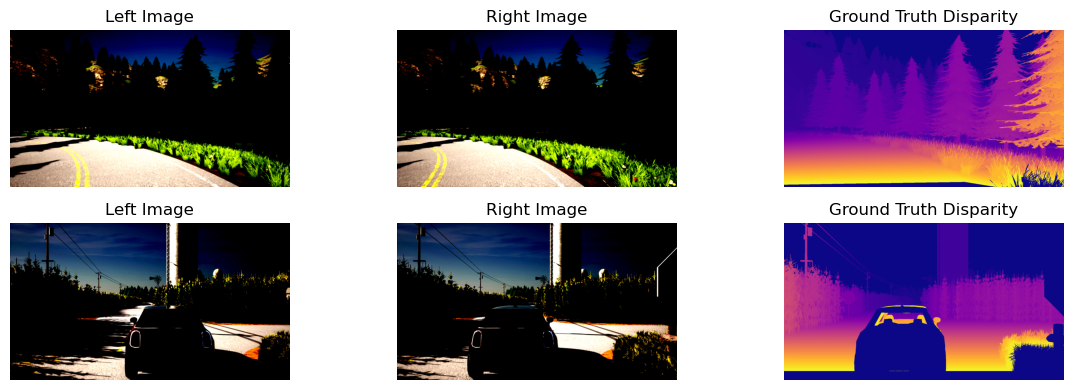

In [6]:
# Testing the test DataLoader
import matplotlib.pyplot as plt

imgL, imgR, disp_L = next(iter(TestImgLoader))

num_samples = min(2, imgL.size(0))
plt.figure(figsize=(12, 2 * num_samples))

for i in range(num_samples):
    # Left Image
    plt.subplot(num_samples, 3, 3*i + 1)
    plt.imshow(imgL[i].permute(1, 2, 0).numpy())
    plt.title("Left Image")
    plt.axis("off")
    
    # Right Image
    plt.subplot(num_samples, 3, 3*i + 2)
    plt.imshow(imgR[i].permute(1, 2, 0).numpy())
    plt.title("Right Image")
    plt.axis("off")
    
    # Disparity Map
    plt.subplot(num_samples, 3, 3*i + 3)
    plt.imshow(disp_L[i].squeeze().numpy(), cmap="plasma")
    plt.title("Ground Truth Disparity")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
# Model and training parameters
maxdisp = 192
epochs = 1
learning_rate = 0.001
model_name = 'stackhourglass'
cuda_available = torch.cuda.is_available()
loadmodel = "best_checkpointLRSE.tar"
savemodel = './'

if model_name == 'stackhourglass':
    model = stackhourglass(maxdisp)
elif model_name == 'basic':
    model = basic(maxdisp)
else:
    raise ValueError('Model not recognized')

if cuda_available:
    model = nn.DataParallel(model)
    model.cuda()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999))

start_epoch = 1
best_val_loss = float('inf')

if loadmodel is not None and os.path.exists(loadmodel):
    print(f"Loading checkpoint from {loadmodel}")
    state_dict = torch.load(loadmodel)
    model.load_state_dict(state_dict['state_dict'])
    optimizer.load_state_dict(state_dict['optimizer'])
    start_epoch = state_dict['epoch'] + 1
    best_val_loss = state_dict['test_loss']
    print(f"Resuming training from epoch {start_epoch}")

def train(imgL, imgR, disp_L):
    model.train()
    imgL = Variable(torch.FloatTensor(imgL))
    imgR = Variable(torch.FloatTensor(imgR))
    disp_L = Variable(torch.FloatTensor(disp_L))

    if cuda_available:
        imgL, imgR, disp_true = imgL.cuda(), imgR.cuda(), disp_L.cuda()

    mask = (disp_true > 0)
    mask.detach_()

    optimizer.zero_grad()

    if model_name == 'stackhourglass':
        output1, output2, output3 = model(imgL, imgR)
        output1 = torch.squeeze(output1, 1)
        output2 = torch.squeeze(output2, 1)
        output3 = torch.squeeze(output3, 1)
        loss = 0.5 * F.smooth_l1_loss(output1[mask], disp_true[mask], size_average=True) + \
               0.7 * F.smooth_l1_loss(output2[mask], disp_true[mask], size_average=True) + \
               F.smooth_l1_loss(output3[mask], disp_true[mask], size_average=True)
    elif model_name == 'basic':
        output = model(imgL, imgR)
        output = torch.squeeze(output, 1)
        loss = F.smooth_l1_loss(output[mask], disp_true[mask], size_average=True)

    loss.backward()
    optimizer.step()

    return loss.item()


def test(imgL, imgR, disp_true):
    model.eval()

    imgL = Variable(torch.FloatTensor(imgL))
    imgR = Variable(torch.FloatTensor(imgR))
    
    if cuda_available:
        imgL, imgR = imgL.cuda(), imgR.cuda()

    with torch.no_grad():
        output3 = model(imgL,imgR)

    pred_disp = output3.data.cpu()
    pred_disp = torch.squeeze(pred_disp,1)

    disp_true = disp_true.cpu()
    mask = (disp_true > 0)
    loss = torch.mean(torch.abs(pred_disp[mask] - disp_true[mask]))

    return loss

In [8]:
# TRAINING LOOP FOR 3 EPOCHS
start_full_time = time.time()

for epoch in range(start_epoch, epochs + 1):
    total_train_loss = 0
    total_test_loss = 0

    ## Training ##
    for batch_idx, (imgL_crop, imgR_crop, disp_crop_L) in enumerate(TrainImgLoader):
        start_time = time.time()
        loss = train(imgL_crop, imgR_crop, disp_crop_L)
        print(f'Epoch {epoch}, Iter {batch_idx} training loss = {loss:.3f}, time = {(time.time() - start_time):.2f}')
        total_train_loss += loss
    print(f'epoch {epoch} total training loss = {total_train_loss / len(TrainImgLoader):.3f}')

    ## Validation ##
    for batch_idx, (imgL, imgR, disp_L) in enumerate(TestImgLoader):
        test_loss = test(imgL, imgR, disp_L)
        print(f'Iter {batch_idx} validation loss = {test_loss:.3f}')
        total_test_loss += test_loss
    
    avg_test_loss = total_test_loss / len(TestImgLoader)
    print(f'epoch {epoch} total validation loss = {avg_test_loss:.3f}')

    # Saving best checkpoint
    if avg_test_loss < best_val_loss:
        best_val_loss = avg_test_loss
        savefilename = os.path.join(savemodel, 'best_checkpointLRSE.tar')
        torch.save({
            'epoch': epoch,
            'state_dict': model.state_dict(),
            'optimizer': optimizer.state_dict(), # <-- Save optimizer state
            'train_loss': total_train_loss / len(TrainImgLoader),
            'test_loss': avg_test_loss,
        }, savefilename)
        print(f"Saved best model at epoch {epoch} with validation loss {avg_test_loss:.3f}")

print('Full training time = %.2f HR' % ((time.time() - start_full_time) / 3600))

/home/prath_linux/anaconda3/envs/cnn/lib/python3.10/site-packages/torch/nn/_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='mean' instead.
  warnings.warn(warning.format(ret))


Epoch 1, Iter 0 training loss = 186.129, time = 95.35
Epoch 1, Iter 1 training loss = 8.518, time = 87.16
Epoch 1, Iter 2 training loss = 0.615, time = 89.27
Epoch 1, Iter 3 training loss = 0.288, time = 87.16
Epoch 1, Iter 4 training loss = 0.259, time = 89.54
Epoch 1, Iter 5 training loss = 0.246, time = 89.47
Epoch 1, Iter 6 training loss = 0.236, time = 87.07
Epoch 1, Iter 7 training loss = 0.241, time = 89.57
Epoch 1, Iter 8 training loss = 0.234, time = 89.71


KeyboardInterrupt: 

In [ ]:
# TESTING FOR 3 EPOCHS
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.autograd import Variable
import random

def plot_disparity_static(imgL, imgR, disp_true, model, focal_length, baseline):
    model.eval()
    if cuda_available:
        imgL = imgL.cuda()
        imgR = imgR.cuda()

    with torch.no_grad():
        pred_disp = model(imgL, imgR)

    pred_disp = pred_disp.squeeze().cpu().numpy()
    
    fig, axes = plt.subplots(3, 1, figsize=(10, 10))
    
    # Show Left Image
    axes[0].imshow(imgL.squeeze().permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Left Image")
    axes[0].axis('off')

    # Show Ground Truth Disparity
    axes[1].imshow(disp_true.squeeze().cpu().numpy(), cmap='plasma')
    axes[1].set_title("Ground Truth Disparity")
    axes[1].axis('off')
    
    # Show Predicted Disparity
    im = axes[2].imshow(pred_disp, cmap='plasma')
    axes[2].set_title("Predicted Disparity with Distance Legend")
    axes[2].axis('off')
    
    # Get the min and max disparity from the prediction to set the colorbar range
    min_disp = np.percentile(pred_disp[pred_disp > 0], 5) 
    max_disp = np.percentile(pred_disp, 95)
    
    cbar = fig.colorbar(im, ax=axes[2], orientation='horizontal', fraction=0.046, pad=0.04)
    cbar.set_label('Disparity Value')
    ticks = cbar.get_ticks()
    
    # Calculate the corresponding distances and create new labels
    distance_labels = []
    for disp_val in ticks:
        if disp_val > 0:
            distance = (focal_length * baseline) / disp_val
            distance_labels.append(f'{distance:.1f}m')
        else:
            distance_labels.append('Inf') # Infinite distance for zero disparity
            
    cbar.ax.set_xticklabels(distance_labels)

    plt.show()

# FOR EPOCH 3
FOCAL_LENGTH = 721 
BASELINE = 0.54 

if model_name == 'stackhourglass':
    model = stackhourglass(maxdisp)
else:
    model = basic(maxdisp)
    
if cuda_available:
    model = nn.DataParallel(model)
    model.cuda()
    
state_dict = torch.load('./best_checkpointLRSE.tar')
model.load_state_dict(state_dict['state_dict'])

# Get a batch of test data
imgL, imgR, disp_L = next(iter(TestImgLoader))

# Pick a random index from this batch
rand_idx = random.randint(0, imgL.size(0) - 1)

# Plot for that random image
plot_disparity_static(
    imgL[rand_idx].unsqueeze(0), 
    imgR[rand_idx].unsqueeze(0), 
    disp_L[rand_idx].unsqueeze(0), 
    model,
    focal_length=FOCAL_LENGTH,
    baseline=BASELINE
)

In [ ]:
# TRAINING LOOP FOR 5 EPOCHS
start_full_time = time.time()

for epoch in range(start_epoch, epochs + 1):
    total_train_loss = 0
    total_test_loss = 0

    ## Training ##
    for batch_idx, (imgL_crop, imgR_crop, disp_crop_L) in enumerate(TrainImgLoader):
        start_time = time.time()
        loss = train(imgL_crop, imgR_crop, disp_crop_L)
        print(f'Epoch {epoch}, Iter {batch_idx} training loss = {loss:.3f}, time = {(time.time() - start_time):.2f}')
        total_train_loss += loss
    print(f'epoch {epoch} total training loss = {total_train_loss / len(TrainImgLoader):.3f}')

    ## Validation ##
    for batch_idx, (imgL, imgR, disp_L) in enumerate(TestImgLoader):
        test_loss = test(imgL, imgR, disp_L)
        print(f'Iter {batch_idx} validation loss = {test_loss:.3f}')
        total_test_loss += test_loss
    
    avg_test_loss = total_test_loss / len(TestImgLoader)
    print(f'epoch {epoch} total validation loss = {avg_test_loss:.3f}')

    # Save best checkpoint
    if avg_test_loss < best_val_loss:
        best_val_loss = avg_test_loss
        savefilename = os.path.join(savemodel, 'best_checkpointLRSE.tar')
        torch.save({
            'epoch': epoch,
            'state_dict': model.state_dict(),
            'optimizer': optimizer.state_dict(), 
            'train_loss': total_train_loss / len(TrainImgLoader),
            'test_loss': avg_test_loss,
        }, savefilename)
        print(f"Saved best model at epoch {epoch} with validation loss {avg_test_loss:.3f}")

print('Full training time = %.2f HR' % ((time.time() - start_full_time) / 3600))

In [ ]:
# TESTING FOR 5 EPOCHS
FOCAL_LENGTH = 721 
BASELINE = 0.54 

if model_name == 'stackhourglass':
    model = stackhourglass(maxdisp)
else:
    model = basic(maxdisp)
    
if cuda_available:
    model = nn.DataParallel(model)
    model.cuda()
    
state_dict = torch.load('./best_checkpointLRSE.tar')
model.load_state_dict(state_dict['state_dict'])

imgL, imgR, disp_L = next(iter(TestImgLoader))
rand_idx = random.randint(0, imgL.size(0) - 1)

plot_disparity_static(
    imgL[rand_idx].unsqueeze(0), 
    imgR[rand_idx].unsqueeze(0), 
    disp_L[rand_idx].unsqueeze(0), 
    model,
    focal_length=FOCAL_LENGTH,
    baseline=BASELINE
)